In [4]:
import os
import cv2
import math
import matplotlib.pyplot as plt
import numpy as np
import random
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoModelForImageClassification, AutoImageProcessor
import torch
from torch.utils.data import DataLoader
from PIL import Image
import os
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR


In [ ]:

def extract_frames(video_path, output_folder, frame_interval=5):
    """
    Extract frames from video at regular intervals and save them as images.
    
    Args:
        video_path (str): Path to the video file.
        output_folder (str): Folder to save extracted frames.
        frame_interval (int): Interval between frames to save (e.g., every 5 frames).
    """
    # Create output folder if it doesn't exist
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    # Load video
    cap = cv2.VideoCapture(video_path)
    frame_count = 0
    extracted_count = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        # Extract every `frame_interval` frames
        if frame_count % frame_interval == 0:
            frame_filename = os.path.join(output_folder, f"frame_{extracted_count}.jpg")
            cv2.imwrite(frame_filename, frame)
            extracted_count += 1
        frame_count += 1

    cap.release()

# Setting the dataset path based on your dataset name in Kaggle
dataset_path = "/kaggle/input/hmdb-human-activity-recognition/HMDB_dataset"  # Corrected path
output_path = "/kaggle/working/frames"  # Correct output path

# Traverse each action folder (e.g., 'eat', 'jump', etc.)
for action in os.listdir(dataset_path):
    action_folder = os.path.join(dataset_path, action)
    if os.path.isdir(action_folder):
        # Traverse each video in the action folder (e.g., 'training_1.avi', 'testing_1.avi')
        for video_file in os.listdir(action_folder):
            if video_file.endswith('.avi'):  # Only process .avi video files
                video_path = os.path.join(action_folder, video_file)
                
                # Create output folder for this video (e.g., 'testing_1', 'training_1')
                video_output_folder = os.path.join(output_path, action, video_file.split('.')[0])
                
                # Ensure that the output folder exists
                if not os.path.exists(video_output_folder):
                    os.makedirs(video_output_folder)
                
                # Extract frames from the video and save them in the corresponding folder
                extract_frames(video_path, video_output_folder)

print("Frames extraction completed.")


In [5]:

def extract_frames(video_path, output_folder, frame_interval=5):
    """
    Extract frames from video at regular intervals and save them as images.
    
    Args:
        video_path (str): Path to the video file.
        output_folder (str): Folder to save extracted frames.
        frame_interval (int): Interval between frames to save (e.g., every 5 frames).
    """
    # Create output folder if it doesn't exist
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    # Load video
    cap = cv2.VideoCapture(video_path)
    frame_count = 0
    extracted_count = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        # Extract every `frame_interval` frames
        if frame_count % frame_interval == 0:
            frame_filename = os.path.join(output_folder, f"frame_{extracted_count}.jpg")
            cv2.imwrite(frame_filename, frame)
            extracted_count += 1
        frame_count += 1

    cap.release()

# Setting the dataset path based on your dataset name in Kaggle
dataset_path = "/kaggle/input/hmdb-human-activity-recognition/HMDB_dataset"  # Corrected path
output_path = "/kaggle/working/frames"  # Correct output path

# Traverse each action folder (e.g., 'eat', 'jump', etc.)
for action in os.listdir(dataset_path):
    action_folder = os.path.join(dataset_path, action)
    if os.path.isdir(action_folder):
        # Separate files into training and testing based on filename
        training_videos = [f for f in os.listdir(action_folder) if f.startswith('training') and f.endswith('.avi')]
        testing_videos = [f for f in os.listdir(action_folder) if f.startswith('testing') and f.endswith('.avi')]
        
        # Process only half of the training videos and one-third of the testing videos
        half_training_count = math.ceil(len(training_videos) / 2)
        third_testing_count = math.ceil(len(testing_videos) / 3)
        
        # Select the first half of training videos
        for video_file in training_videos[:half_training_count]:
            video_path = os.path.join(action_folder, video_file)
            video_output_folder = os.path.join(output_path, action, video_file.split('.')[0])
            if not os.path.exists(video_output_folder):
                os.makedirs(video_output_folder)
            extract_frames(video_path, video_output_folder)
        
        # Select the first third of testing videos
        for video_file in testing_videos[:third_testing_count]:
            video_path = os.path.join(action_folder, video_file)
            video_output_folder = os.path.join(output_path, action, video_file.split('.')[0])
            if not os.path.exists(video_output_folder):
                os.makedirs(video_output_folder)
            extract_frames(video_path, video_output_folder)

print("Frames extraction completed for selected training and testing videos.")


Frames extraction completed for selected training and testing videos.


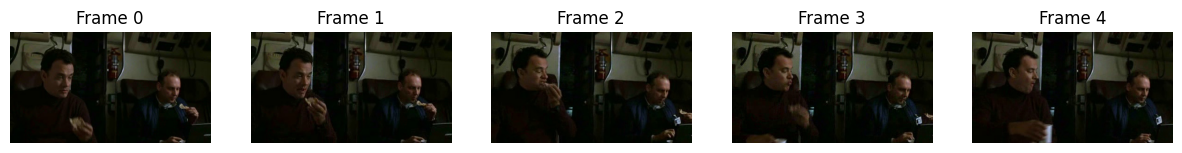

In [6]:

def visualize_frames(action, video_name, num_frames=5):
    """
    Visualizes the first `num_frames` frames from a specific action and video.
    
    Args:
        action (str): Action category (e.g., 'jump', 'kiss').
        video_name (str): Video name (e.g., 'training_16').
        num_frames (int): Number of frames to display.
    """
    # Path to the extracted frames folder
    frames_folder = f"/kaggle/working/frames/{action}/{video_name}"
    
    # List the frames in the folder
    frames = sorted(os.listdir(frames_folder))
    
    # Display the first `num_frames` frames
    plt.figure(figsize=(15, 5))
    for i in range(min(num_frames, len(frames))):
        frame_path = os.path.join(frames_folder, frames[i])
        frame = cv2.imread(frame_path)
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # Convert to RGB for matplotlib
        plt.subplot(1, num_frames, i + 1)
        plt.imshow(frame_rgb)
        plt.axis('off')
        plt.title(f"Frame {i}")
    plt.show()


visualize_frames('eat', 'training_17', num_frames=5)  


In [7]:


def preprocess_frame(frame):
    """
    Preprocess the frame (resize, crop, flip, normalize).
    
    Args:
        frame (ndarray): The input frame to preprocess.
        
    Returns:
        processed_frame (ndarray): The preprocessed frame.
    """
    # Resize the frame to 224x224
    processed_frame = cv2.resize(frame, (224, 224))

    # Apply random data augmentation
    processed_frame = random_augmentation(processed_frame)

    # Normalize the frame (mean and std for ImageNet pre-trained ViT models)
    #processed_frame = normalize_frame(processed_frame)
    
    return processed_frame

def random_augmentation(frame):
    """
    Apply random augmentation to the frame (e.g., flipping, cropping).
    
    Args:
        frame (ndarray): The input frame to augment.
        
    Returns:
        frame (ndarray): The augmented frame.
    """
    # Randomly apply horizontal flip
    if random.random() > 0.5:
        frame = cv2.flip(frame, 1)  # Horizontal flip
    
    # Randomly crop a portion of the frame based on its dimensions
    height, width, _ = frame.shape
    crop_size = int(min(height, width) * 0.9)  # Crop 90% of the smallest dimension
    start_x = random.randint(0, width - crop_size)
    start_y = random.randint(0, height - crop_size)
    frame = frame[start_y:start_y + crop_size, start_x:start_x + crop_size]

    # Resize back to 224x224 after cropping
    frame = cv2.resize(frame, (224, 224))
    
    return frame

def normalize_frame(frame):
    """
    Normalize the frame (mean and std normalization for ViT).
    
    Args:
        frame (ndarray): The input frame to normalize.
        
    Returns:
        frame (ndarray): The normalized frame.
    """
    # Convert to float and scale to [0, 1]
    frame = frame.astype(np.float32) / 255.0
    
    # ImageNet mean and std for normalization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    # Normalize
    frame = (frame - mean) / std
    
    return frame

def preprocess_frames_in_folder(input_folder, output_folder):
    """
    Preprocess all frames in a folder and save them as .jpg files.
    
    Args:
        input_folder (str): Folder with the original frames.
        output_folder (str): Folder to save the preprocessed frames.
    """
    # Traverse all files in the folder
    for root, _, files in os.walk(input_folder):
        for file in files:
            # Check for image file extensions
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                frame_path = os.path.join(root, file)
                
                # Read the frame
                frame = cv2.imread(frame_path)
                if frame is None:  # Check if image was read successfully
                    print(f"Warning: {frame_path} could not be read.")
                    continue

                # Preprocess the frame
                preprocessed_frame = preprocess_frame(frame)
                
                # Convert the normalized image back to [0, 255]
                preprocessed_frame = (preprocessed_frame )
                
                # Determine the relative folder structure for saving
                relative_path = os.path.relpath(root, input_folder)
                output_frame_folder = os.path.join(output_folder, relative_path)
                
                # Ensure the output folder exists
                if not os.path.exists(output_frame_folder):
                    os.makedirs(output_frame_folder)

                # Save the preprocessed frame as a .jpg file
                output_frame_path = os.path.join(output_frame_folder, file)
                cv2.imwrite(output_frame_path, preprocessed_frame)

                # Optional: Uncomment to verify by saving a sample frame
                # if random.random() < 0.01:  # Save a few random samples for verification
                #     cv2.imwrite(f"/kaggle/working/sample_{file}", preprocessed_frame)

# Setting the dataset paths for your Kaggle environment
input_path = "/kaggle/working/frames"  # Folder with the original frames
output_path = "/kaggle/working/preprocessed_frames"  # Folder for preprocessed frames

# Process frames in the dataset folder and save to the new location
preprocess_frames_in_folder(input_path, output_path)

print("Frame preprocessing and saving completed.")


Frame preprocessing and saving completed.


Displaying 5 images from preprocessed_frames:


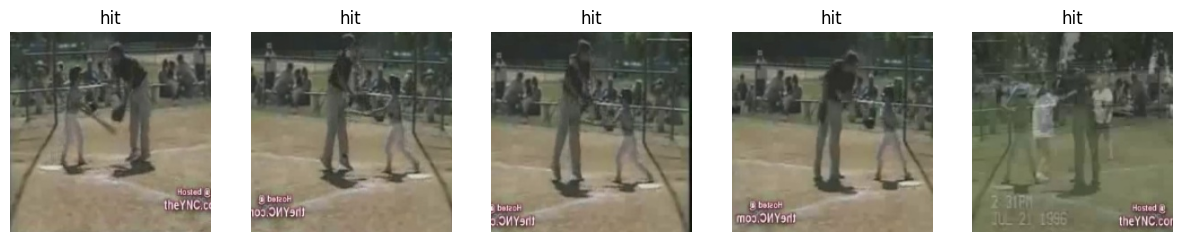

In [8]:


# Function to display images directly from a folder
def show_images_from_folder(data_path, n_images=5):
    # Get the list of categories (subfolders) in the data path
    categories = os.listdir(data_path)
    
    # Initialize an empty list to hold image paths and labels
    all_images = []
    all_labels = []

    # Loop through categories and their subdirectories
    for category in categories[1:]:
        category_path = os.path.join(data_path, category)

        # Only process subfolders
        if os.path.isdir(category_path):
            for subfolder in os.listdir(category_path):
                subfolder_path = os.path.join(category_path, subfolder)

                # Process only 'training' or 'testing' subfolders
                if os.path.isdir(subfolder_path) and (subfolder.startswith('training') or subfolder.startswith('testing')):
                    for filename in os.listdir(subfolder_path):
                        if filename.endswith('.jpg'):
                            img_path = os.path.join(subfolder_path, filename)
                            all_images.append(img_path)
                            all_labels.append(category)  # Label based on the folder name

    # Load a batch of images
    images = all_images[:n_images]
    labels = all_labels[:n_images]

    # Set up the plot
    fig, axes = plt.subplots(1, n_images, figsize=(15, 5))

    # Loop through the images and labels
    for i in range(n_images):
        ax = axes[i]
        
        # Open the image
        image = Image.open(images[i]).convert('RGB')  # Convert to RGB if not already
        
        ax.imshow(image)  # Display the image
        ax.set_title(labels[i])  # Display the label as the title
        ax.axis('off')  # Hide the axes

    plt.show()

# Define the base path where preprocessed frames are stored
base_path = '/kaggle/working/preprocessed_frames'

# Display 5 images from the preprocessed_frames folder
print("Displaying 5 images from preprocessed_frames:")
show_images_from_folder(base_path)


In [9]:


# Define the path for the processed frames
base_path = '/kaggle/working/preprocessed_frames'

def load_data(data_path, is_test=False):
    categories = os.listdir(data_path)
    all_images = []
    all_labels = []

    for category in categories:
        category_path = os.path.join(data_path, category)
        for subfolder in os.listdir(category_path):
            subfolder_path = os.path.join(category_path, subfolder)
            if os.path.isdir(subfolder_path):
                if (is_test and subfolder.startswith('testing')) or \
                   (not is_test and subfolder.startswith('training')):
                    for filename in os.listdir(subfolder_path):
                        if filename.endswith('.jpg'):
                            img_path = os.path.join(subfolder_path, filename)
                            all_images.append(img_path)
                            all_labels.append(category)

    print(f"Loaded {len(all_images)} images for {'testing' if is_test else 'training'}.")
    return all_images, all_labels

# Load images and create datasets
train_images, train_labels = load_data(base_path, is_test=False)
test_images, test_labels = load_data(base_path, is_test=True)

# Label encoder to encode labels
label_encoder = LabelEncoder()
train_labels_encoded = label_encoder.fit_transform(train_labels)
test_labels_encoded = label_encoder.transform(test_labels)

# Load pretrained ViT model and image processor
model_name = 'google/vit-base-patch16-224-in21k'
image_processor = AutoImageProcessor.from_pretrained(model_name, use_fast=True)
num_classes = len(label_encoder.classes_)
model = AutoModelForImageClassification.from_pretrained(model_name, num_labels=num_classes)

# Custom Dataset class
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, image_paths, labels, image_processor):
        self.image_paths = image_paths
        self.labels = labels
        self.image_processor = image_processor

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        label = self.labels[idx]
        
        # Load and process the image
        image = Image.open(image_path).convert('RGB')
        image = self.image_processor(images=image, return_tensors="pt")['pixel_values'].squeeze(0)
        
        return image, label

# Create datasets and DataLoader
train_dataset = CustomDataset(train_images, train_labels_encoded, image_processor)
test_dataset = CustomDataset(test_images, test_labels_encoded, image_processor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Print number of batches
print(f"Number of batches in train_loader: {len(train_loader)}")
print(f"Number of batches in test_loader: {len(test_loader)}")


Loaded 48715 images for training.
Loaded 10288 images for testing.


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Number of batches in train_loader: 1523
Number of batches in test_loader: 322


In [10]:

# Set up the optimizer and scheduler
learning_rate = 5e-5  # Fine-tune learning rate
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

# Learning rate scheduler to decrease the learning rate after every 5 epochs
scheduler = StepLR(optimizer, step_size=5, gamma=0.1)

batch_size = 32  # Can be adjusted based on your GPU/CPU capacity
epochs = 10  # Start with 10 epochs and adjust based on performance
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:

model = model.to(device)
# Define best_accuracy and early_stopping_patience
best_accuracy = 0.0 
early_stopping_patience = 3

# Training loop with checkpointing and early stopping
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_preds = 0
    total_preds = 0
    
    # Wrapping the training loop with tqdm for progress bar
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} (Training)', unit='batch'):
        # Move images and labels to the same device as the model
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images).logits
        loss = F.cross_entropy(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # Calculate accuracy
        _, preds = torch.max(outputs, 1)
        correct_preds += torch.sum(preds == labels)
        total_preds += labels.size(0)
    
    # Calculate training accuracy
    train_accuracy = correct_preds / total_preds

    # Validation phase
    model.eval()
    with torch.no_grad():
        correct_preds = 0
        total_preds = 0
        # Wrapping the validation loop with tqdm for progress bar
        for images, labels in tqdm(test_loader, desc=f'Epoch {epoch+1}/{epochs} (Validation)', unit='batch'):
            # Ensure test data is moved to the same device
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images).logits
            _, preds = torch.max(outputs, 1)
            correct_preds += torch.sum(preds == labels)
            total_preds += labels.size(0)

        # Calculate validation accuracy
        val_accuracy = correct_preds / total_preds

    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {running_loss/len(train_loader):.4f}, Train Accuracy: {train_accuracy:.4f}, Validation Accuracy: {val_accuracy:.4f}")

    # Early stopping condition
    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        epochs_without_improvement = 0
        # Save the model with the best validation accuracy
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= early_stopping_patience:
            print("Early stopping")
            break

    # Step the learning rate scheduler
    scheduler.step()


Epoch 1/10 (Validation): 100%|██████████| 322/322 [01:00<00:00,  5.35batch/s]


Epoch [1/10], Train Loss: 1.2734, Train Accuracy: 0.7668, Validation Accuracy: 0.8088


Epoch 2/10 (Validation): 100%|██████████| 322/322 [01:00<00:00,  5.35batch/s]


Epoch [2/10], Train Loss: 0.1577, Train Accuracy: 0.9692, Validation Accuracy: 0.8278


Epoch 3/10 (Validation): 100%|██████████| 322/322 [01:00<00:00,  5.36batch/s]


...

Epoch [8/10], Train Loss: 0.0033, Train Accuracy: 0.9995, Validation Accuracy: 0.8439


Epoch 9/10 (Validation): 100%|██████████| 322/322 [01:00<00:00,  5.35batch/s]


Epoch [9/10], Train Loss: 0.0025, Train Accuracy: 0.9996, Validation Accuracy: 0.8455


Epoch 10/10 (Validation): 100%|██████████| 322/322 [01:00<00:00,  5.35batch/s]


Epoch [10/10], Train Loss: 0.0020, Train Accuracy: 0.9997, Validation Accuracy: 0.8485


/tmp/ipykernel_30/2776445336.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))  # Uncomment if necessary


Test Loss: 0.8346
Test Accuracy: 0.8485

Classification Report:
                precision    recall  f1-score   support

    brush_hair       1.00      0.95      0.97       545
     cartwheel       0.70      0.46      0.55        96
         catch       0.95      0.99      0.97        81
          chew       0.98      0.96      0.97       257
          clap       0.86      0.93      0.90       163
         climb       0.97      0.97      0.97       340
  climb_stairs       0.93      0.93      0.93       169
          dive       0.80      0.81      0.80       119
    draw_sword       0.82      0.87      0.85       167
       dribble       1.00      0.93      0.96       288
         drink       0.47      0.60      0.53       153
           eat       0.22      0.44      0.29        64
    fall_floor       0.42      0.53      0.47        86
       fencing       0.98      0.90      0.94       111
     flic_flac       0.78      1.00      0.87       153
          golf       1.00      1.00    

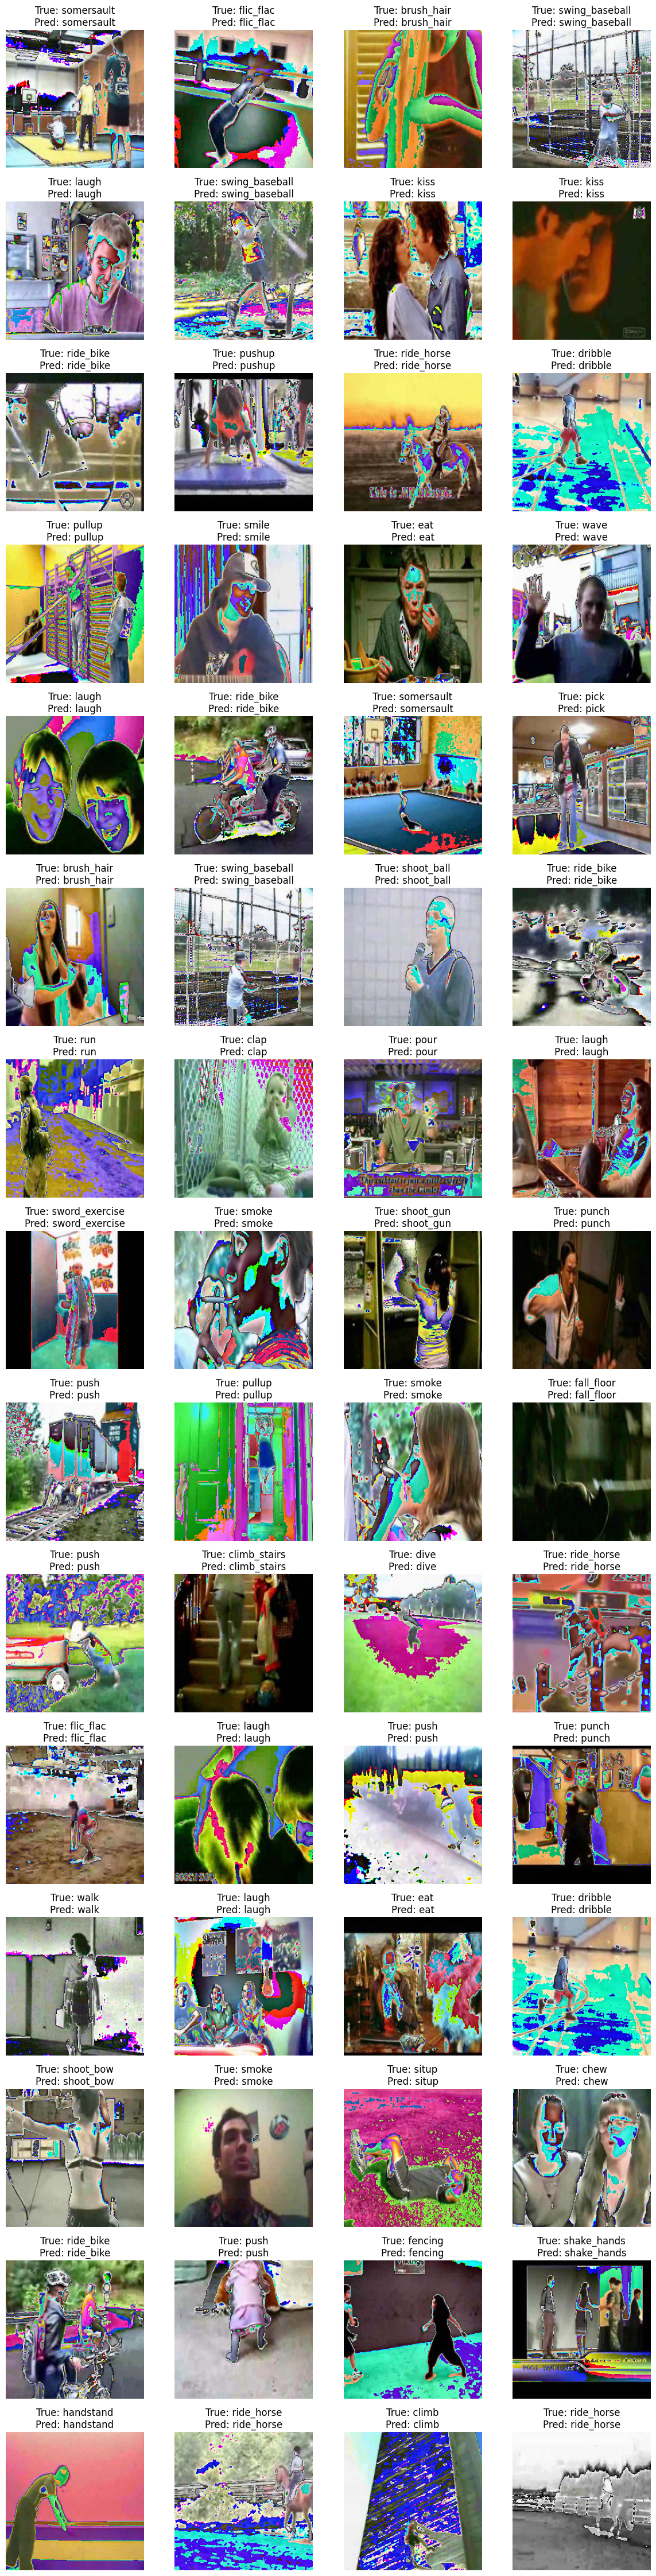

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader

# Function to plot all images with their true and predicted labels, showing only correct predictions
def visualize_all_predictions(images, true_labels, predicted_labels, class_names, max_images=60, images_per_row=4):
    """
    Visualizes all images along with their true and predicted labels.
    Limits the number of images to `max_images` to avoid excessive plotting.
    Only shows images where the prediction is correct.
    Displays images in rows with `images_per_row` images in each row.
    """
    # Convert tensors to numpy arrays for processing
    images = images.cpu().numpy()
    true_labels = true_labels.cpu().numpy()
    predicted_labels = predicted_labels.cpu().numpy()

    # Filter for correct predictions
    correct_idx = np.where(true_labels == predicted_labels)[0]

    # Limit the number of images to visualize
    num_images = min(len(correct_idx), max_images)
    
    # Calculate number of rows needed for displaying images
    num_rows = (num_images + images_per_row - 1) // images_per_row  # Ceil division

    # Set up the subplot grid
    fig, axes = plt.subplots(num_rows, images_per_row, figsize=(images_per_row * 3, num_rows * 3))

    # Flatten axes array in case of multiple rows
    axes = axes.flatten()

    for i in range(num_images):
        ax = axes[i]
        idx = correct_idx[i]
        img = np.transpose(images[idx], (1, 2, 0))  # Convert from (C, H, W) to (H, W, C)
        
        # Resize the image for better display if it is too large
        img_pil = Image.fromarray((img * 255).astype(np.uint8))  # Convert to uint8 and then to PIL image
        img_pil.thumbnail((300, 300))  # Resize to fit in the plot
        img_resized = np.array(img_pil)
        
        ax.imshow(img_resized)
        ax.set_title(f"True: {class_names[true_labels[idx]]}\nPred: {class_names[predicted_labels[idx]]}")
        ax.axis('off')

    # Hide any unused axes
    for i in range(num_images, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Load your model (if not already done)
model.load_state_dict(torch.load('best_model.pth'))  # Uncomment if necessary
model.eval()  # Set model to evaluation mode

# Loss function
criterion = nn.CrossEntropyLoss()

# Initialize metrics
correct_preds = 0
total_preds = 0
total_loss = 0.0

# For storing data for visualization
all_images = []
all_true_labels = []
all_predicted_labels = []

# Assuming test_loader is defined elsewhere
# Set `shuffle=True` in your DataLoader to get random images
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)  # Ensure this is set properly

# Evaluate the model on the test set
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)  # Assuming you're using a device (GPU/CPU)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        
        # Extract the logits (raw class scores) from the output
        logits = outputs.logits
        
        # Calculate the loss
        loss = criterion(logits, labels)
        
        # Track loss
        total_loss += loss.item()

        # Get predictions
        _, preds = torch.max(outputs.logits, 1)
        
        # Track correct predictions and total predictions
        correct_preds += torch.sum(preds == labels)
        total_preds += labels.size(0)
        
        # Collect all images, true labels, and predictions for visualization
        all_images.append(images.cpu())
        all_true_labels.append(labels.cpu())
        all_predicted_labels.append(preds.cpu())

# Concatenate all batches for visualization and metrics
all_images = torch.cat(all_images)
all_true_labels = torch.cat(all_true_labels)
all_predicted_labels = torch.cat(all_predicted_labels)

# Calculate metrics
test_loss = total_loss / len(test_loader)
test_accuracy = correct_preds.item() / total_preds

# Print the metrics
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
class_names = label_encoder.classes_  # Assuming you're using label_encoder from your dataset
print(classification_report(all_true_labels.numpy(), all_predicted_labels.numpy(), target_names=class_names))

# Visualize all images with their true and predicted labels (only correct predictions)
visualize_all_predictions(all_images, all_true_labels, all_predicted_labels, class_names)


In [18]:
import zipfile
import os
from IPython.display import FileLink

# Path to the model file and the ZIP file
model_path = '/kaggle/working/best_model.pth'
zip_path = '/kaggle/working/model.zip' 

# Check if the model file exists
if os.path.exists(model_path):
    # Create the ZIP file
    with zipfile.ZipFile(zip_path, 'w') as zipf:
        zipf.write(model_path, os.path.basename(model_path))
    print(f"Model zipped successfully: {zip_path}")
else:
    print("Model file not found in the working directory.")
    
# Ensure the ZIP file is created
if os.path.exists(zip_path):
    print(f"ZIP file created successfully: {zip_path}")
    # Create a clickable download link for the ZIP file
    display(FileLink(zip_path))
else:
    print("Failed to create the ZIP file.")


Model zipped successfully: /kaggle/working/model.zip
ZIP file created successfully: /kaggle/working/model.zip


/kaggle/working/model.zip